In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras import layers, models

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [4]:
x_train = train.drop('label', axis=1)
y_train = train['label']

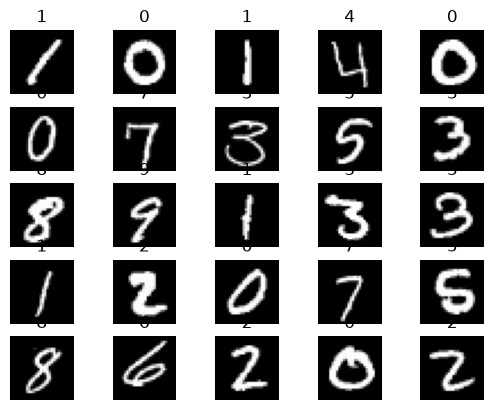

In [6]:
plt.figsize = (10, 10)
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train.iloc[i].values.reshape(28, 28), cmap = 'gray')
    plt.title(y_train.iloc[i])
    plt.axis('off')

In [9]:
x_train = x_train.values.reshape(-1, 28, 28, 1)
x_train = x_train / 255.0
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)

In [10]:
y_train

array([[0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(42000, 10))

In [14]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(16, (3,3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(10, activation ='softmax'))

In [15]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics =['accuracy'])

In [16]:
model.fit(x_train, y_train, epochs = 10, validation_split =0.2, batch_size =128)

Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8433 - loss: 0.5155 - val_accuracy: 0.9526 - val_loss: 0.1606
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9602 - loss: 0.1277 - val_accuracy: 0.9674 - val_loss: 0.1054
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9719 - loss: 0.0921 - val_accuracy: 0.9744 - val_loss: 0.0851
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9767 - loss: 0.0743 - val_accuracy: 0.9795 - val_loss: 0.0677
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9802 - loss: 0.0648 - val_accuracy: 0.9799 - val_loss: 0.0634
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9824 - loss: 0.0563 - val_accuracy: 0.9827 - val_loss: 0.0567
Epoch 7/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9840 - loss: 0.0513 - val_accuracy: 0.9826 - val_loss: 0.0567
Epoch 8/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9859 - loss: 0.0453 - val_accu

In [18]:
x_test = test.values.reshape(-1, 28, 28, 1)
x_test = x_test / 255.0
y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis =1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [19]:
y_pred

array([2, 0, 9, ..., 3, 9, 2], shape=(28000,))

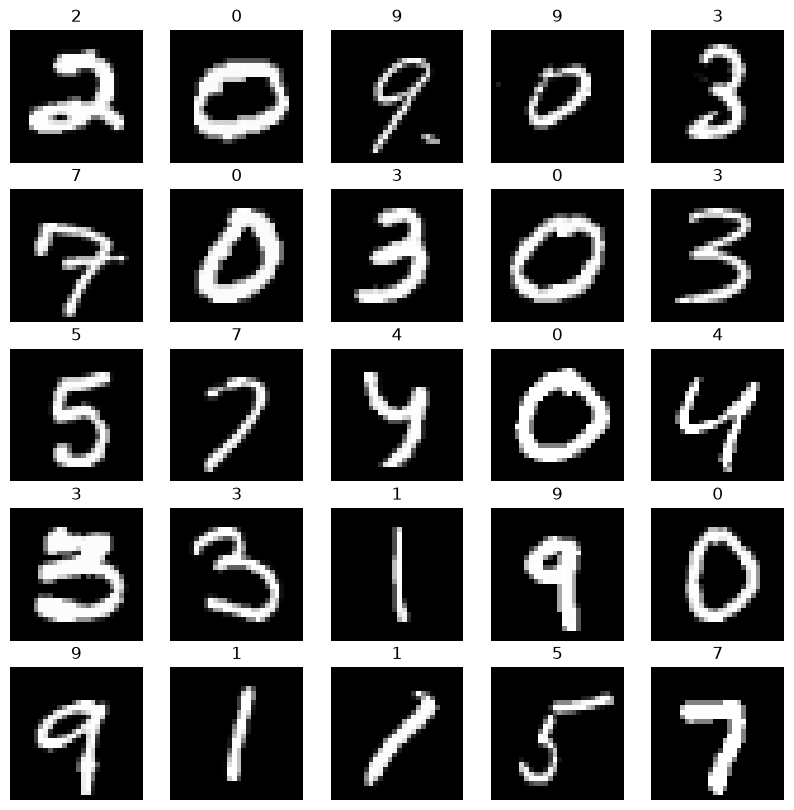

In [21]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(test.iloc[i].values.reshape(28, 28), cmap = 'gray')
    plt.title(y_pred[i])
    plt.axis('off')

In [22]:
submission = pd.DataFrame({'ImageId': range(1, 28001), 'label': y_pred})

In [25]:
submission.to_csv('submission.csv', index = False)